# V3 - Transfer Learning (ResNet50)
## Plant Disease Detection — Fine-tuning ResNet50 pre-trained su ImageNet (38 classi)

In [1]:
# ── Cella 1: Setup & Imports ─────────────────────────────
import sys, os, json, time, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

# ── Paths ────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
MODELS_DIR   = RESULTS_DIR / "models" / "v3_transfer_learning"
METRICS_DIR  = RESULTS_DIR / "metrics"
PLOTS_DIR    = RESULTS_DIR / "plots"

for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Device (MPS su Apple Silicon, CUDA se disponibile, altrimenti CPU) ────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ── Hyperparameters ──────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 64
LR_BACKBONE   = 1e-4   # fine-tuning lento per layer4
LR_HEAD       = 1e-3   # head nuova: può imparare più in fretta
EPOCHS        = 50
PATIENCE      = 5
NUM_WORKERS   = 0

FAST_MODE = False
print(f"Fast mode: {FAST_MODE}")

Device: mps
PyTorch: 2.12.0
Fast mode: False


In [2]:
# ── Cella 2: Dataset & DataLoaders ─────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(DATA_DIR / "val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(DATA_DIR / "test",  transform=val_test_transform)

if FAST_MODE:
    def subsample(ds, frac=0.1):
        n = max(1, int(len(ds) * frac))
        idx = torch.randperm(len(ds))[:n].tolist()
        return torch.utils.data.Subset(ds, idx)
    train_dataset = subsample(train_dataset)
    val_dataset   = subsample(val_dataset)
    test_dataset  = subsample(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = train_dataset.classes if hasattr(train_dataset, "classes") else train_dataset.dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classi: {NUM_CLASSES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classi: 38
Train: 70295 | Val: 8777 | Test: 8795


In [3]:
# ── Cella 3: ResNet50 con Custom Head (freeze layer1-3, fine-tune layer4) ──
def build_resnet50_transfer(num_classes=38):
    """ResNet50 pre-trained su ImageNet:
       - stem, layer1, layer2, layer3 → FROZEN (feature extractor)
       - layer4 → UNFROZEN (fine-tuning con lr basso)
       - fc rimpiazzata da head Linear(2048→512)+ReLU+Dropout+Linear(512→num_classes)
    """
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    net = models.resnet50(weights=weights)

    # 1. congela tutto
    for p in net.parameters():
        p.requires_grad = False

    # 2. sgela layer4 (ultimi 3 bottleneck blocks, 512 channels)
    for p in net.layer4.parameters():
        p.requires_grad = True

    # 3. nuova head: Linear(2048→512) + ReLU + Dropout(0.5) + Linear(512→num_classes)
    net.fc = nn.Sequential(
        nn.Linear(net.fc.in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes),
    )
    return net


model = build_resnet50_transfer(num_classes=NUM_CLASSES).to(DEVICE)

# Conteggio parametri
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"Parametri totali:     {total_params:,}  (~{total_params/1e6:.1f}M)")
print(f"Parametri frozen:     {frozen_params:,}  (~{frozen_params/1e6:.1f}M)")
print(f"Parametri trainable:  {trainable_params:,}  (~{trainable_params/1e6:.1f}M)")

# ── Loss + Optimizer con learning rates differenziali ──────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": LR_BACKBONE},
    {"params": model.fc.parameters(),     "lr": LR_HEAD},
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=3)
print(f"\nOptimizer: Adam | layer4 lr={LR_BACKBONE} | head lr={LR_HEAD}")
print("Modello, loss e optimizer pronti ✅")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/marco/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 24.1MB/s]


Parametri totali:     24,576,614  (~24.6M)
Parametri frozen:     8,543,296  (~8.5M)
Parametri trainable:  16,033,318  (~16.0M)

Optimizer: Adam | layer4 lr=0.0001 | head lr=0.001
Modello, loss e optimizer pronti ✅


In [4]:
# ── Cella 4: Training Loop con Early Stopping (con resume) ─────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += images.size(0)
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += images.size(0)
    return running_loss / total, correct / total


checkpoint_path = MODELS_DIR / "checkpoint.pth"

# ── Resume dal checkpoint se esiste ────────────────────────────
if checkpoint_path.exists():
    ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    best_val_loss  = ckpt["val_loss"]
    start_epoch    = ckpt["epoch"] + 1
    history        = ckpt.get("history", {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []})
    print(f"Ripreso da epoch {ckpt['epoch']} — best val loss {best_val_loss:.4f}, val acc {ckpt['val_acc']:.4f}")
else:
    best_val_loss  = float("inf")
    start_epoch    = 1
    history        = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    print("Nessun checkpoint trovato, training da zero.")

best_model_wts = copy.deepcopy(model.state_dict())
patience_count = 0
t0 = time.time()

print(f"Training su {DEVICE} — epoch {start_epoch}→{EPOCHS}, early stopping patience={PATIENCE}\n")

for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    improved = vl_loss < best_val_loss
    if improved:
        best_val_loss  = vl_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({"epoch": epoch,
                    "model_state_dict": best_model_wts,
                    "val_loss": best_val_loss,
                    "val_acc": vl_acc,
                    "history": history}, checkpoint_path)
        patience_count = 0
        tag = " ✓ saved"
    else:
        patience_count += 1
        tag = f" (patience {patience_count}/{PATIENCE})"

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {vl_loss:.4f} acc {vl_acc:.4f}{tag}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping a epoch {epoch}.")
        break

elapsed = time.time() - t0
print(f"\nTraining completato in {elapsed/60:.1f} min")
print(f"Best val loss: {best_val_loss:.4f}")

with open(METRICS_DIR / "v3_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("History salvata ✅")

/Users/marco/Documents/repos/ComputerVisionProject/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Nessun checkpoint trovato, training da zero.
Training su mps — epoch 1→50, early stopping patience=5

Epoch   1/50 | train loss 0.2367 acc 0.9312 | val loss 0.0409 acc 0.9870 ✓ saved
Epoch   2/50 | train loss 0.0500 acc 0.9838 | val loss 0.0227 acc 0.9929 ✓ saved
Epoch   3/50 | train loss 0.0321 acc 0.9896 | val loss 0.0328 acc 0.9894 (patience 1/5)
Epoch   4/50 | train loss 0.0243 acc 0.9922 | val loss 0.0184 acc 0.9952 ✓ saved
Epoch   5/50 | train loss 0.0216 acc 0.9935 | val loss 0.0338 acc 0.9904 (patience 1/5)
Epoch   6/50 | train loss 0.0177 acc 0.9947 | val loss 0.0177 acc 0.9950 ✓ saved
Epoch   7/50 | train loss 0.0167 acc 0.9949 | val loss 0.0179 acc 0.9964 (patience 1/5)
Epoch   8/50 | train loss 0.0157 acc 0.9954 | val loss 0.0267 acc 0.9943 (patience 2/5)
Epoch   9/50 | train loss 0.0137 acc 0.9959 | val loss 0.0156 acc 0.9964 ✓ saved
Epoch  10/50 | train loss 0.0112 acc 0.9967 | val loss 0.0178 acc 0.9949 (patience 1/5)
Epoch  11/50 | train loss 0.0123 acc 0.9965 | val los

In [5]:
# ── Cella 5: Evaluate sul Test Set ──────────────────────────────
# carica il best checkpoint
ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

metrics = {
    "model":    "V3_ResNet50_TransferLearning",
    "accuracy": round(acc,  4),
    "precision": round(prec, 4),
    "recall":   round(rec,  4),
    "f1":       round(f1,   4),
    "best_epoch": int(ckpt["epoch"]),
    "training_time_min": round(elapsed / 60, 2),
    "trainable_params": int(trainable_params),
    "total_params":     int(total_params),
}
with open(METRICS_DIR / "v3_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("── V3 Metrics ───────────────────────────")
for k, v in metrics.items():
    print(f"  {k}: {v}")
print("Salvato in results/metrics/v3_metrics.json ✅")

── V3 Metrics ───────────────────────────
  model: V3_ResNet50_TransferLearning
  accuracy: 0.9987
  precision: 0.9988
  recall: 0.9987
  f1: 0.9987
  best_epoch: 19
  training_time_min: 127.81
  trainable_params: 16033318
  total_params: 24576614
Salvato in results/metrics/v3_metrics.json ✅


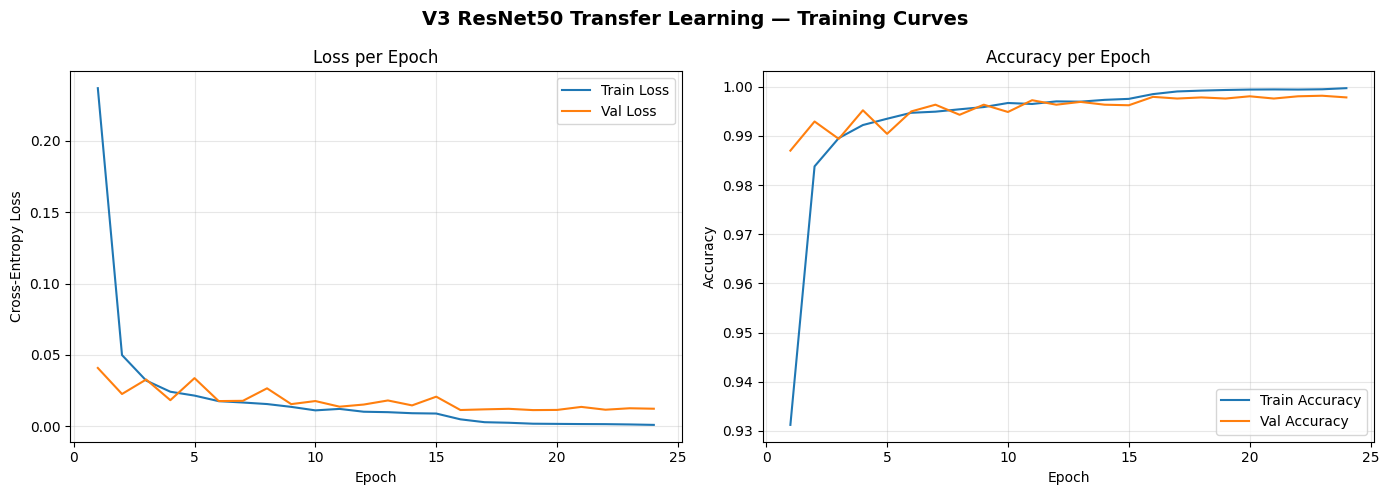

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/plots/v3_training_curves.png ✅


In [6]:
# ── Cella 6: Training Curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_acc"], label="Train Accuracy")
axes[1].plot(epochs_ran, history["val_acc"],   label="Val Accuracy")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("V3 ResNet50 Transfer Learning — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
out_path = PLOTS_DIR / "v3_training_curves.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_path} ✅")

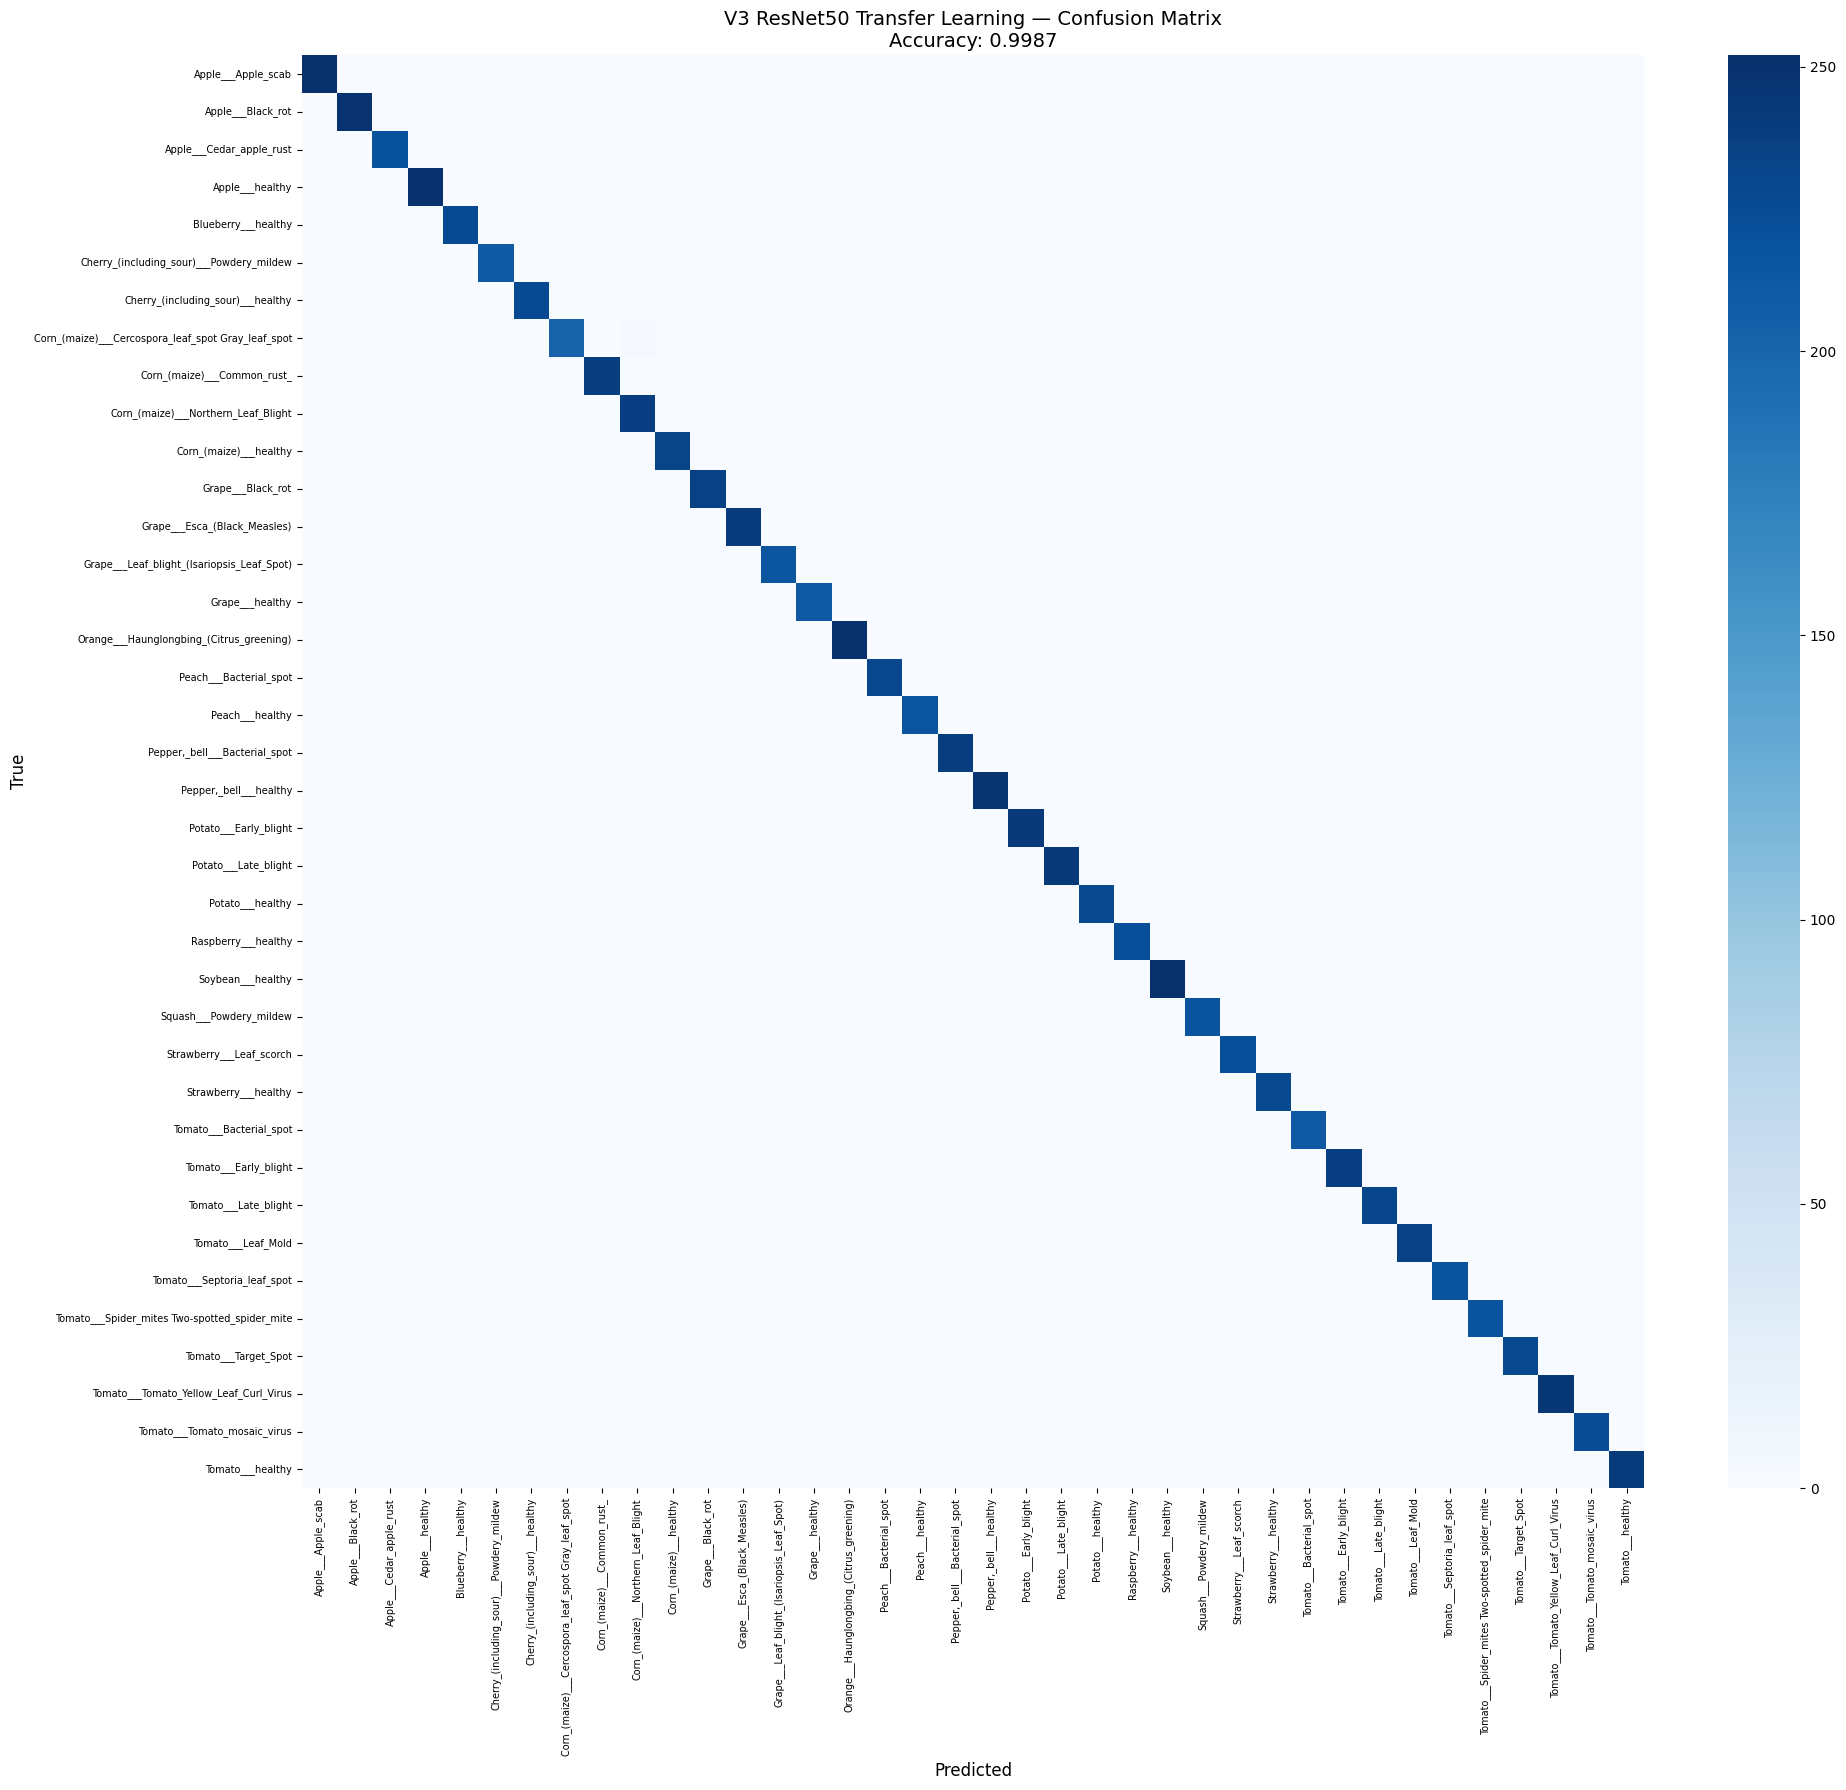

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/plots/v3_confusion_matrix.png ✅


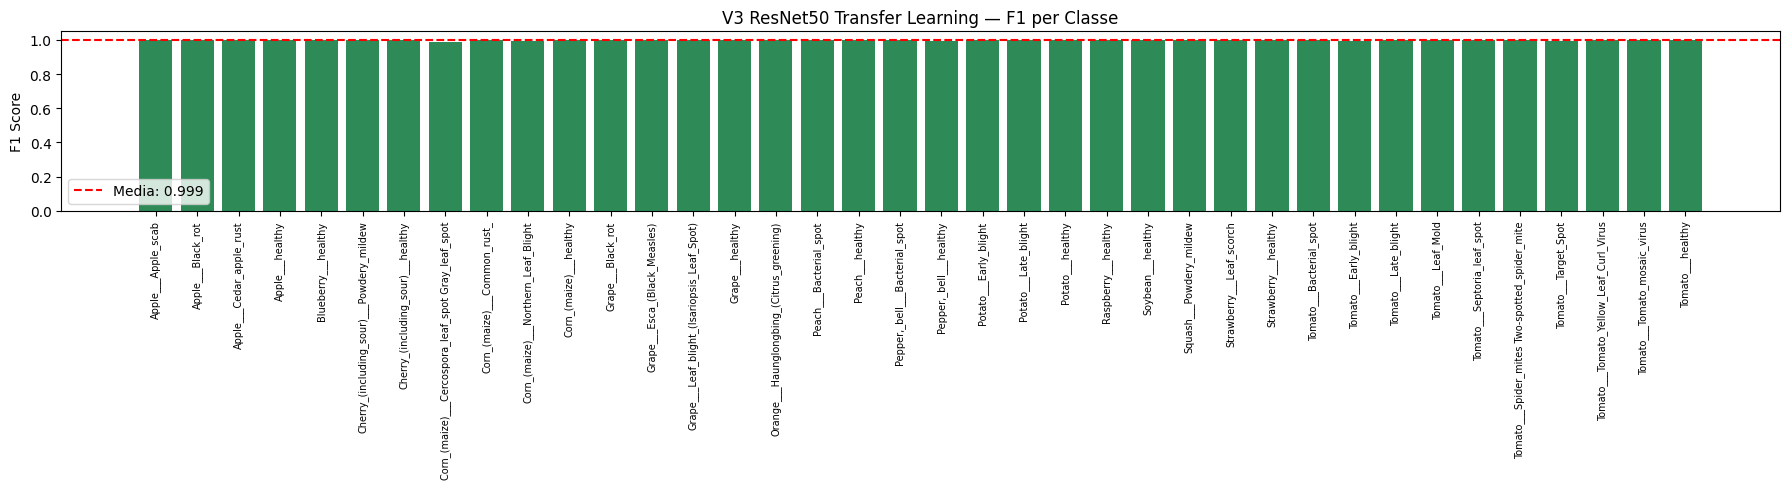

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/plots/v3_f1_per_class.png ✅

Done! Notebook 03 completato.


In [7]:
# ── Cella 7: Confusion Matrix + F1 per Classe ────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"V3 ResNet50 Transfer Learning — Confusion Matrix\nAccuracy: {acc:.4f}", fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
out_path = PLOTS_DIR / "v3_confusion_matrix.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_path} ✅")

# F1 per classe
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
fig2, ax2 = plt.subplots(figsize=(18, 5))
bars = ax2.bar(CLASS_NAMES, f1_per_class, color="seagreen")
ax2.set_xticks(range(len(CLASS_NAMES)))
ax2.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax2.set_ylabel("F1 Score")
ax2.set_title("V3 ResNet50 Transfer Learning — F1 per Classe")
ax2.set_ylim(0, 1.05)
ax2.axhline(f1_per_class.mean(), color="red", linestyle="--", label=f"Media: {f1_per_class.mean():.3f}")
ax2.legend()
plt.tight_layout()
out_path2 = PLOTS_DIR / "v3_f1_per_class.png"
plt.savefig(out_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_path2} ✅")
print("\nDone! Notebook 03 completato.")